In [ ]:
# Require installations.
!pip install scipy
!pip install qiskit==1.1.0
!pip install qiskit qiskit-aer
!pip install qiskit-ibm-runtime
!pip install pennylane==0.35.0
!pip install openfermionpyscf
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.4/39.4 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.3/343.3 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 432.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 8.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pennylane-lightning to determine which version is compatible with other requirements. Th

In [1]:
# from qiskit import QuantumCircuit
# from qiskit import transpile
# #from qiskit_ionq import IonQProvider
# #from qiskit.providers.jobstatus import JobStatus
# from qiskit_ibm_runtime import QiskitRuntimeService, Session, Sampler
# import time
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
#from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import QiskitRuntimeService



In [45]:
from qiskit.providers.fake_provider import GenericBackendV2
service = QiskitRuntimeService()
# backend = service.least_busy(simulator=False, operational=True)
# backend = Aer.get_backend('aer_simulator')
backend = GenericBackendV2(num_qubits=6)

In [46]:
circuit = QuantumCircuit(6,6)
circuit.h(0)
circuit.x(1)
circuit.h(2) # I also change the order ZH
circuit.z(2)
circuit.barrier()
circuit.h([4])
#add_cswap(circuit, control_qubit=4, target_qubit1=3, target_qubit2=1)
circuit.cswap(4, 3, 1)
#add_cswap(circuit, control_qubit=4, target_qubit1=2, target_qubit2=0)
circuit.cswap(4, 2, 0)
circuit.h([4])
circuit.barrier()
circuit.h(5)
#add_cswap(circuit, control_qubit=5, target_qubit1=3, target_qubit2=1)
circuit.cswap(5,2,0)
circuit.h(5)
circuit.barrier()
circuit.measure([0,1,2,3,4,5], [0,1,2,3,4,5])
#decomposed_circuit=circuit.decompose().decompose().decompose()
# compiled_circuit=transpile(decomposed_circuit,qpu)
print(circuit.draw())
# depth=compiled_circuit.depth()
# print(depth)
# print(decomposed_circuit)
# print(compiled_circuit.draw())


     ┌───┐      ░                  ░               ░ ┌─┐               
q_0: ┤ H ├──────░──────────X───────░───────X───────░─┤M├───────────────
     ├───┤      ░          │       ░       │       ░ └╥┘┌─┐            
q_1: ┤ X ├──────░───────X──┼───────░───────┼───────░──╫─┤M├────────────
     ├───┤┌───┐ ░       │  │       ░       │       ░  ║ └╥┘┌─┐         
q_2: ┤ H ├┤ Z ├─░───────┼──X───────░───────X───────░──╫──╫─┤M├─────────
     └───┘└───┘ ░       │  │       ░       │       ░  ║  ║ └╥┘┌─┐      
q_3: ───────────░───────X──┼───────░───────┼───────░──╫──╫──╫─┤M├──────
                ░ ┌───┐ │  │ ┌───┐ ░       │       ░  ║  ║  ║ └╥┘┌─┐   
q_4: ───────────░─┤ H ├─■──■─┤ H ├─░───────┼───────░──╫──╫──╫──╫─┤M├───
                ░ └───┘      └───┘ ░ ┌───┐ │ ┌───┐ ░  ║  ║  ║  ║ └╥┘┌─┐
q_5: ───────────░──────────────────░─┤ H ├─■─┤ H ├─░──╫──╫──╫──╫──╫─┤M├
                ░                  ░ └───┘   └───┘ ░  ║  ║  ║  ║  ║ └╥┘
c: 6/═════════════════════════════════════════════════╩══╩══╩══╩

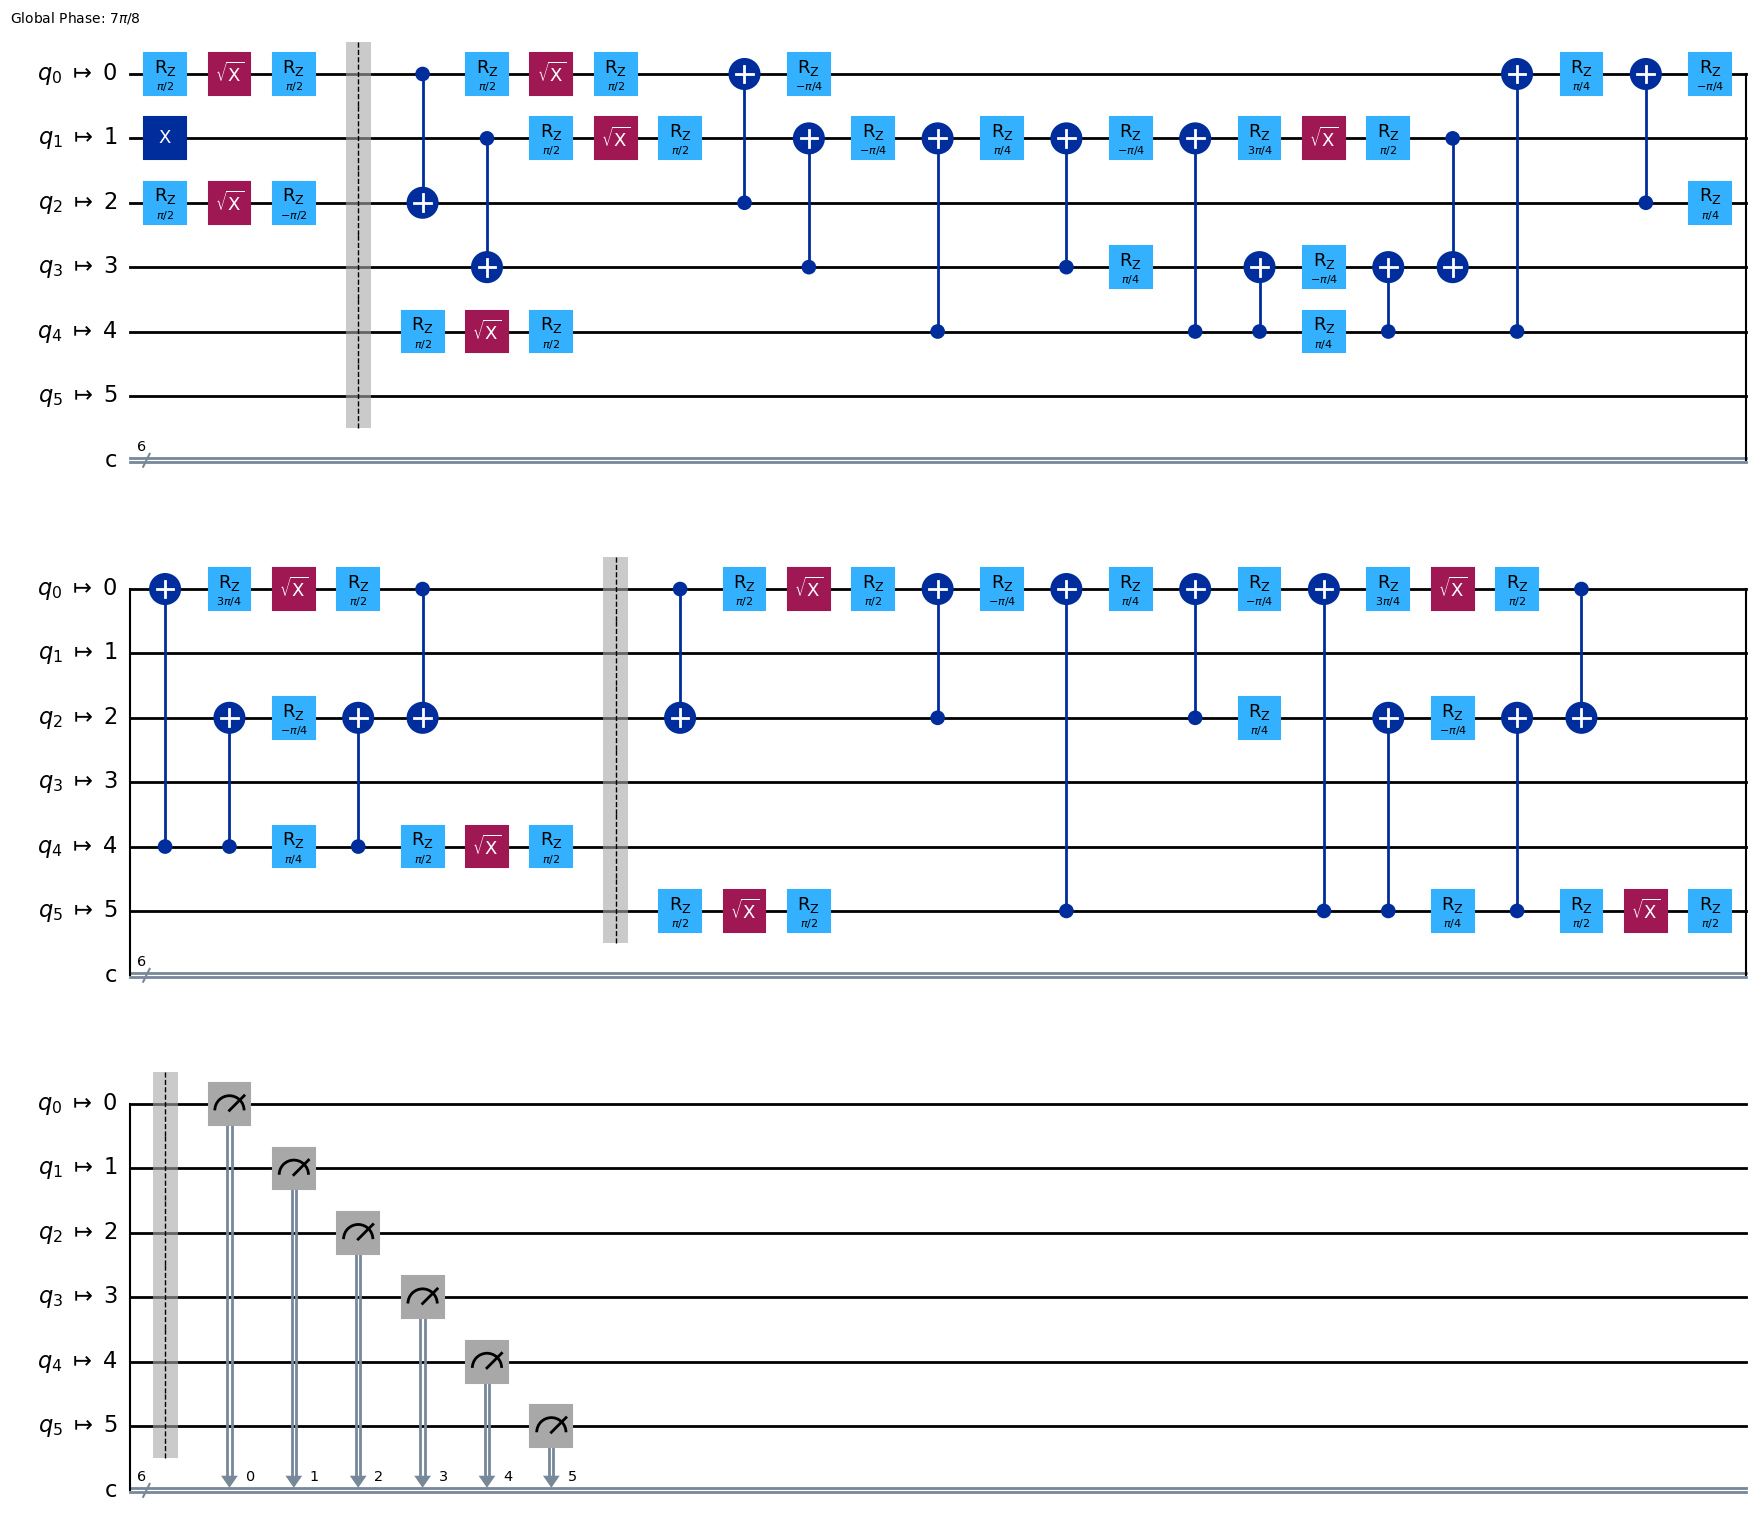

In [54]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
#isa_circuit = pm.run(decomposed_circuit)
isa_circuit = pm.run(circuit)


isa_circuit.draw('mpl', idle_wires=False)

In [80]:

from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
# job = sampler.run([isa_circuit])
job = sampler.run([isa_circuit],shots=10000)

In [96]:
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")
job_result = job.result()
job.result()[0].data['c'].get_counts() ## this is changed


>>> Job ID: ccfc0309-a57e-49e9-9dda-982702759fec
>>> Job Status: JobStatus.DONE


{'111100': 565,
 '111101': 25,
 '111001': 555,
 '110110': 520,
 '101001': 549,
 '000010': 644,
 '100110': 532,
 '011000': 608,
 '001100': 29,
 '011101': 612,
 '101100': 553,
 '010111': 584,
 '010010': 634,
 '001000': 649,
 '100011': 574,
 '001101': 618,
 '110011': 555,
 '000111': 604,
 '100010': 20,
 '010011': 27,
 '000011': 29,
 '100101': 2,
 '000110': 26,
 '010101': 21,
 '110111': 17,
 '000000': 10,
 '011100': 34,
 '110010': 30,
 '000101': 17,
 '111011': 18,
 '101101': 27,
 '100100': 11,
 '101000': 27,
 '010110': 33,
 '001010': 17,
 '100111': 23,
 '111110': 12,
 '011001': 32,
 '101011': 10,
 '110001': 13,
 '101110': 16,
 '111000': 19,
 '001001': 19,
 '001111': 14,
 '100001': 23,
 '011010': 5,
 '011111': 6,
 '010000': 13,
 '110100': 11,
 '001011': 1,
 '000001': 2,
 '001110': 1,
 '011011': 2,
 '010100': 2}

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
 
# Generate a 5-qubit simulated backend
backend = GenericBackendV2(num_qubits=5)
 
# Create a simple circuit
circuit = QuantumCircuit(3)
circuit.h(0)
circuit.cx(0,1)
circuit.cx(0,2)
circuit.measure_all()
circuit.draw('mpl')
 
# Transpile the ideal circuit to a circuit that can be directly executed by the backend
transpiled_circuit = transpile(circuit, backend)
transpiled_circuit.draw('mpl')
 
# Run the transpiled circuit using the simulated backend
job = backend.run(transpiled_circuit)
counts = job.result().get_counts()

In [43]:
#get the result
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

job = service.job('055c4c87-21e4-4647-a0c9-806cfb0e12c4')
counts = job.result().get_counts()
# To get counts for a particular pub result, use
#
# pub_result = job_result[<idx>].data.<classical register>.get_counts()
#
# where <idx> is the index of the pub and <classical register> is the name of the classical register.
# You can use circuit.cregs to find the name of the classical registers.


RuntimeJobNotFound: 'Job not found: 404 Client Error: Not Found for url: https://api.quantum.ibm.com/runtime/jobs/055c4c87-21e4-4647-a0c9-806cfb0e12c4. {"errors":[{"code":1291,"message":"Job not found. Job ID: 055c4c87-21e4-4647-a0c9-806cfb0e12c4","solution":"Verify the job ID is correct, and that you have the correct access permissions.","more_info":"https://docs.quantum-computing.ibm.com/errors"}]}'